In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.constants as const
import matplotlib as mpl
import matplotlib.gridspec as gridspec

import seaborn as sns
import xarray as xr

from scipy.special import k0
from scipy.constants import k
from scipy.optimize import curve_fit
from dataclasses import dataclass

## Constants and calibrational data

In [2]:
# ------------------ Physical constants ------------------
Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1
Delta_Al = 3.4e-4*e # J


# ------------------ System parameters ------------------
T = 40e-3 #K
Ec= 0.233e9*h #JAC
C = e**2/(2*Ec) #F

Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm^2

## Data loading and preprocessing

In [3]:
def process_datasets(two_tone_path, t1_path, flux_scale, flux_offset, pad_length):
    two_tone_ds = xr.load_dataset(two_tone_path)
    t1_ds = xr.load_dataset(t1_path)

    ds_copy = two_tone_ds.copy(deep=True)

    flux_f01 = ds_copy.setpoint + flux_offset
    freq_f01 = ds_copy.f01

    # Filtering T1 data
    valid_idx = (t1_ds.T1 < 40e-6) & ~np.isnan(t1_ds.T1) & (t1_ds.T1_err < 1e-6)
    clean_flux = t1_ds.setpoint[valid_idx]
    clean_t1 = t1_ds.T1[valid_idx]
    clean_t1_err = t1_ds.T1_err[valid_idx]

    flux_t1 = clean_flux*flux_scale + flux_offset
    data_t1 = clean_t1

    # Padding
    padded_flux = np.pad(clean_flux, (0, pad_length - len(clean_flux)), 'constant')
    padded_t1 = np.pad(clean_t1, (0, pad_length - len(clean_flux)), 'constant')
    padded_t1_err = np.pad(clean_t1_err, (0, pad_length - len(clean_flux)), 'constant')

    # Replace zeroes with NaN
    t1_nan = np.where(padded_t1 == 0, np.nan, padded_t1)
    t1_err_nan = np.where(padded_t1_err == 0, np.nan, padded_t1_err)

    return {
        'flux_f01': flux_f01,
        'freq_f01': freq_f01,
        'flux_t1': flux_t1,
        'data_t1': data_t1,
        'padded_flux': padded_flux,
        'padded_t1': t1_nan,
        'padded_t1_err': t1_err_nan
    }

# === Call function for each dataset ===

In [4]:
dataset_1 = process_datasets(
    "Data/Q2_DS_1/DS_1_sweep_qcodes_f01_combined.hdf5",
    "Data/Q2_DS_1/DS_1_sweep_qcodes_t1_combined.hdf5",
    flux_scale = 1.0753, 
    flux_offset=1.775,
    pad_length=228
)


dataset_2 = process_datasets(
    "Data/Q2_DS_2/DS_2_sweep_quantify_f01_combined.hdf5",
    "Data/Q2_DS_2/DS_2_sweep_quantify_t1_combined.hdf5",
    flux_scale = 1.0753, 
    flux_offset=1.77631,
    pad_length=228
)

dataset_3 = process_datasets(
    "Data/Q2_DS_3/DS_3_sweep_quantify_f01_combined.hdf5",
    "Data/Q2_DS_3/DS_3_sweep_quantify_t1_combined.hdf5",
    flux_scale = 1.0753, 
    flux_offset=1.778,
    pad_length=364
)

dataset_4 = process_datasets(
    "Data/Q2_DS_4/DS_4_sweep_quantify_f01_combined.hdf5",
    "Data/Q2_DS_4/DS_4_sweep_quantify_t1_combined.hdf5",
    flux_scale = 1.0753, 
    flux_offset=1.7788,
    pad_length=364
)


## Hamiltonian construction

In [5]:
def build_phase_hamiltonians(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        ng: float,
) -> np.ndarray:

    """
    Construct phase-basis Hamiltonians for a superconducting circuit.
    """
    # ----------------- Phase grid -----------------
    phis = phis * 2*np.pi
    N = len(phis)
    delta_phi = phis[1] - phis[0]

    # ----------------- Differential operators -----------------
        # First derivative
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Second derivative (Laplacian)
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ----------------- Kinetic term -----------------
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # ----------------- Effective left arm SQUID parameters -----------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    # Transmission coefficients (clipped for stability)
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)

    # ----------------- Capacitances & charging energies for internal modes -----------------

    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

    C_mod_R = CJ3 + CJ45
    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

    # ----------------- Energy scales -----------------
    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff

    # ----------------- Grid reshaping -----------------
    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    V = np.zeros((len(flux1), N, N), dtype=float)

    # ----------------- Potential energy prefactors -----------------
    PF_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    PF_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    PF_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2)
    PF_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2))

    # ----------------- Potential energy -----------------
    V_phi = -(E_L * PF_L + E_R * PF_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])  

    # Effective EJ
    EJ_eff = -np.min(V_phi, axis=1)

    # ----------------- Full Hamiltonian -----------------
    H_all = V + T[None, :, :] 

    return H_all, phis, EJ_eff


In [6]:
a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

## Noise operators calculation

In [7]:
def n_operator_phase(N, delta_phi, ng=0.0):
    # central finite difference for derivative
    t = 1 / (2 * delta_phi)
    n_op = np.zeros((N, N), dtype=complex)
    
    # off-diagonal elements
    for i in range(N-1):
        n_op[i, i+1] = -1j * t
        n_op[i+1, i] = 1j * t
    
    # periodic boundary
    n_op[0, -1] = 1j * t
    n_op[-1, 0] = -1j * t
    
    # offset by ng
    n_op -= ng * np.eye(N)
    
    return n_op


In [8]:
def compute_qubit_properties(EJ1, EJ2, EJ3, EJ4, EJ5, flux1, flux2, phi, Ec, ng, n_max=50):
    
    # Build Hamiltonians
    H_all, phis, EJ_eff = build_phase_hamiltonians(EJ1=EJ1, EJ2=EJ2, EJ3=EJ3,EJ4=EJ4, EJ5=EJ5, flux1=flux1, flux2=flux2, phis=phi, Ec= EC, ng = 0.0)


    # Phase grid
    N = len(phis)
    phi_grid = phis[None, :]
    flux1_grid = flux1[:, None]

    # ------------------ Effective parameters ------------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    EJR = (EJ3 + EJ45eff)
    EJL = EJ1 + EJ2

    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    
    t1, t2 = np.clip(t1, 0, 1), np.clip(t2, 0, 1)
    
    # ------------------ Charging energies ------------------
    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod = CJ45 + CJ3
    EC_mod = e**2/(2*C_mod*h)*1e-9

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9


    # ------------------ Operators ------------------

    delta_phi = phis[1] - phis[0]
    n_op = n_operator_phase(N, delta_phi)

    qp_op_L = np.diag(np.sin(phis/2))# independent of flux
    qp_op_R = np.sin((phi_grid  - 2*np.pi*flux1_grid)/2)# independent of flux

    phi_op = np.diag(phis)

    # ==========================DERIVATIVE OPERATORS (FLUX)================================

    # ------------- Change parqameters------------

    theta = (phi_grid - 2*np.pi*flux1_grid)/2
    
    PF_R = np.sqrt(1 - t2 * np.sin(theta)**2)

    sqrt =  np.sqrt(np.cos(np.pi*flux2)**2 + d**2*np.sin(np.pi*flux2)**2)

    d_EJ45eff_dflux2 = EJsum*(np.pi/2)*(d**2-1)*np.sin(2*np.pi*flux2)/(sqrt)

    #  -------- Main potential d flux2 ------
    
    d_t2_d_flux2 = 4*EJ3*(1/EJR)**3*(EJ3-EJ45eff)*d_EJ45eff_dflux2

    d_PF_R_d_t2 = -1/2*(np.sin(theta))**2/PF_R
    
    # -------- Internal mode contribution (flux2) --------

    d_sqrt_EJR_dflux2 = (1/2)*np.sqrt(1/EJR)*d_EJ45eff_dflux2

    d_sqrt_sqrt_PF_dflux2 = (-1/4)*(np.sin(theta))**2*(1 - t2 * (np.sin(theta)**2))**(-3/4)*d_t2_d_flux2

    d_int_mode_dflux2 = np.sqrt(2*EC_mod)*( 
                                                d_sqrt_EJR_dflux2 *(1 - t2 * np.sin(theta)**2)**(1/4)
                                                + np.sqrt(EJR)*d_sqrt_sqrt_PF_dflux2
                                            )

    #  -------- Deriative over flux1 ------
    
    d_EJR_d_flux1 = EJR*t2*(np.pi) * np.sin((2*theta))/(2*np.sqrt(1 - t2 * (np.sin(theta))**2))

    d_int_mode_d_flux1 = np.sqrt(2*EC_mod*EJR)*1/4*t2*(np.pi)*np.sin(2*theta)/(1 - t2 * (np.sin(theta))**2)**(3/4)

    # -------- Total derivatives --------

    d_H_d_flux1 = -(d_EJR_d_flux1 - d_int_mode_d_flux1)

    d_H_d_flux2 = -(d_EJ45eff_dflux2*PF_R + EJR*d_PF_R_d_t2*d_t2_d_flux2 - d_int_mode_dflux2)
    
    # ------------------ Eigenstate extraction ------------------

    freqs_01 = []
    n01_mod_sq_list = []
    phi01_mod_sq_list = []
    flux1_noise_mod_sq_list = []
    flux2_noise_mod_sq_list = []
    qp01_mod_sq_list_L= []
    qp01_mod_sq_list_R = []

    for i, H in enumerate(H_all):

        eigvals, evecs = np.linalg.eigh(H)

        eigvals = np.sort(np.real(eigvals))
        f01 = eigvals[1] - eigvals[0]
        freqs_01.append(f01)

    # ---- charge operator ----
        n_eigen = evecs.conj().T @ n_op @ evecs
        n01 = n_eigen[0,1]
        n01_mod_sq = np.abs(n01)**2
        n01_mod_sq_list.append(n01_mod_sq)

    # ---- phase operator ----
        phi_eigen = evecs.conj().T @ phi_op @ evecs
        phi01 = phi_eigen[0,1]
        phi01_mod_sq = np.abs(phi01)**2
        phi01_mod_sq_list.append(phi01_mod_sq) 

        # ---- flux noise 1 ----
        dH_op_flux1 = np.diag(d_H_d_flux1[i])
        flux1_noise_eigen = evecs.conj().T @ dH_op_flux1 @ evecs
        flux1_noise_01 = flux1_noise_eigen[0,1]
        mod_sq_flux1_noise_01 = np.abs(flux1_noise_01)**2
        flux1_noise_mod_sq_list.append(mod_sq_flux1_noise_01)
        
        # ---- flux noise 2 ----
        dH_op_flux2 = np.diag(d_H_d_flux2[i])
        flux2_noise_eigen = evecs.conj().T @ dH_op_flux2 @ evecs
        flux2_noise_01 = flux2_noise_eigen[0,1]
        mod_sq_flux2_noise_01 = np.abs(flux2_noise_01)**2
        flux2_noise_mod_sq_list.append(mod_sq_flux2_noise_01)

        # ---- qp left ----
        qp_eigen_L = evecs.conj().T @ qp_op_L @ evecs
        qp01_L = qp_eigen_L[0,1]
        qp01_mod_sq_L = np.abs(qp01_L)**2
        qp01_mod_sq_list_L.append(qp01_mod_sq_L) 

        # ---- qp right ----
        qp_op_diag_R = np.diag(qp_op_R[i])
        qp_eigen_R = evecs.conj().T @ qp_op_diag_R @ evecs
        qp01_R = qp_eigen_R[0,1]
        qp01_mod_sq_R = np.abs(qp01_R)**2
        qp01_mod_sq_list_R.append(qp01_mod_sq_R) 
   
    freqs_01 = np.array(freqs_01)
    n_01_mod_sq = np.array(n01_mod_sq_list)
    phi_01_mod_sq = np.array(phi01_mod_sq_list)
    flux1_noise_mod_sq = np.array(flux1_noise_mod_sq_list)
    flux2_noise_mod_sq = np.array(flux2_noise_mod_sq_list)
    qp_01_L_mod_sq = np.array(qp01_mod_sq_list_L)
    qp_01_R_mod_sq = np.array(qp01_mod_sq_list_R)

    return (freqs_01, n_01_mod_sq, phi_01_mod_sq, flux1_noise_mod_sq, flux2_noise_mod_sq, qp_01_L_mod_sq, qp_01_R_mod_sq, EJL, EJR, EJ_eff)



## Noise computation

### Dielectric loss

In [9]:
def Charge_noise(EC, f01, n01, A_cap,  alpha_cap):
    
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (2*k_B * T)
    coth = 1 / np.tanh(therm_ratio)
    thermal_factor = ( 1 + coth )
    
    CJ = e**2 / (2 * EC * 1e9 * h)

    Q_cap = A_cap * (6/f01)**(alpha_cap)
    S_cap =  hbar / (CJ * Q_cap) * coth

    Gamma_cap = hbar**(-2) * n01 * S_cap * (2 * e)**2
    
    return Gamma_cap


### FBL noise

In [ ]:
def FBL_noise_mix(f01, flux1_mx, flux2_mx, M1, M2):
    # To convert the mutual inductance to Henries in this formula, an additional
    # Phi_0 factor would normally appear. However, this factor cancels with the
    # Phi_0 contained in the matrix element during the transition-rate calculation.
    # Since Phi_0 is omitted from the matrix-element calculation here, it is also
    # omitted from the mutual inductance definition.
        
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)

    R = 50

    coef = (h * 1e9)**2 # To convert to energy from GHz

    S_flux1_line = (M1**2*omega01*hbar/R)*coth 

    S_flux2_line = (M2**2*omega01*hbar/R)*coth 

    Gamma_flux1_line = (1 / hbar**2) * coef*flux1_mx * S_flux1_line

    Gamma_flux2_line = (1 / hbar**2) * coef*flux2_mx * S_flux2_line
    
    Gamma_flux12_line = Gamma_flux1_line + Gamma_flux2_line
    
    return Gamma_flux1_line, Gamma_flux2_line, Gamma_flux12_line


### $1/f$ noise

In [ ]:
def one_over_f_noise(f01, flux1_noise, flux2_noise, A_lambda, gamma):
    # Phi_0 cancels in the transition-rate calculation through the product of the
    # noise quality factor and matrix element, so neither the noise operator nor
    # the A_lambda coefficient includes Phi_0.

    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    S_lambda = 2*np.pi*A_lambda**2/(omega01)**gamma

    flux_noise_total = flux1_noise + flux2_noise

    coef = (h * 1e9)**2 # To convert to energy from GHz 

    Gamma_one_over_f =  (1 / hbar**2) * coef * flux_noise_total *  S_lambda 
    
    return Gamma_one_over_f 

### Inductive noise

In [12]:
def Inductive_noise(EJeff, f01, phi_01, A_ind):

    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (2*k_B * T)
    coth = 1 / np.tanh(therm_ratio)

    omega_ref = 2 * np.pi * 0.5e9  # rad/s
    arg_ref = hbar * omega_ref / (2 * k_B * T)                                  

    Q_ind = A_ind * (k0(arg_ref) * np.sinh(arg_ref)) / (k0(therm_ratio) * np.sinh(therm_ratio))

    LJ = (Phi_0/(2*np.pi))**2/(EJeff*h*1e9)                               
    
    coeff = ((Phi_0)/(2*np.pi))**2
                                      
    B_lambda_sq = coeff*phi_01 #Simce matrix element here without the dimention

    S_ind = hbar / (LJ * Q_ind) * coth  #(coth/(1+np.exp(-therm_ratio)))   
                                      
    Gamma_ind = hbar**(-2)*S_ind*B_lambda_sq
    
    return Gamma_ind


### Quasiparticle poisoning

In [13]:
def QP_noise(EJL, EJR, qp_op_L, qp_op_R, f01, x_qp):
    
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (2*k_B * T)
    coth = 1 / np.tanh(therm_ratio)

    Delta = 3.4e-4 * e  

    Rk = h/e**2
    prefactor = np.sqrt(2/np.pi)
    
    energy_ratio_L = (8*EJL*1e9*h/(Rk*Delta))
    energy_ratio_R = (8*EJR*1e9*h/(Rk*Delta))
    
    gap_term = (2*Delta/(hbar*omega01))**(3/2)

    ReY_L = x_qp*prefactor*energy_ratio_L*gap_term*np.sqrt(therm_ratio)*k0(therm_ratio)*np.sinh(therm_ratio)

    ReY_R = x_qp*prefactor*energy_ratio_R*gap_term*np.sqrt(therm_ratio)*k0(therm_ratio)*np.sinh(therm_ratio)

    S_qp_L = hbar*omega01*ReY_L*(1+coth)

    S_qp_R = hbar*omega01*ReY_R*(1+coth)
    
    Gamma_qp_L =  2*(Phi_0/(hbar*np.pi))**2*(qp_op_L)*S_qp_L

    Gamma_qp_R =  2*(Phi_0/(hbar*np.pi))**2*(qp_op_R)*S_qp_R

    Gamma_qp_tot = Gamma_qp_L + Gamma_qp_R

    return Gamma_qp_tot, Gamma_qp_L, Gamma_qp_R


### Purcell decay

In [14]:
def simple_Purcell(f01,  n01, f_res, g):

    Q_L = 4.6e4

    gc = 2 * np.pi *g

    Delta = 2 * np.pi *(f01 - f_res) * 1e9  # Hz

    kappa = 2 * np.pi * f_res * 1e9 / Q_L  # Hz
   
    Gamma_purcell = (gc**2*n01* kappa) / (Delta**2)
    
    return Gamma_purcell

### Noise add up 

In [15]:
def run_qubit_calculation(
        EJ1, EJ2, EJ3, EJ4, EJ5,
        EC, ng, n_max,
        flux2,
        noise,
        phi_ext_range=(0.4, 0.6), phi_samples=151):

    # Prepare flux grids
    phi = np.linspace(0, 1, 151)
    phi_ext = np.linspace(*phi_ext_range, phi_samples)

    # Compute qubit parameters
    f01, n_01_mod_sq, phi_01_mod_sq, flux1_noise_mod_sq, flux2_noise_mod_sq, qp_01_L_mod_sq, qp_01_R_mod_sq, EJL, EJR, EJeff = compute_qubit_properties(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        flux1=phi_ext,
        flux2=flux2,
        phi=phi,
        Ec=EC, ng=ng,
        n_max=n_max
    )

    Gamma_diel_noise = Charge_noise(EC, f01, n_01_mod_sq, A_cap=noise.A_cap,  alpha_cap=noise.alpha_cap)

    Gamma_qp, Gamma_qp_L, Gamma_qp_R = QP_noise(EJL, EJR, qp_01_L_mod_sq, qp_01_R_mod_sq, f01, x_qp=noise.x_qp)

    # Individual channels
    Gamma_ind_noise = Inductive_noise(
            EJeff, f01, phi_01=phi_01_mod_sq, A_ind=noise.A_ind
        )

    Gamma_flux1_line, Gamma_flux2_line, Gamma_flux12_line = FBL_noise_mix(
            f01, flux1_noise_mod_sq, flux2_noise_mod_sq,
            M1=noise.M1, M2=noise.M2
        )

    Gamma_purcell = simple_Purcell(f01, n_01_mod_sq, f_res, g=noise.g)

    Gamma_one_over_f = one_over_f_noise(
            f01, flux1_noise_mod_sq, flux2_noise_mod_sq,
            A_lambda=noise.A_lambda,
            gamma=noise.gamma
        )


        # Total relaxation time
    T_total = 1 / (
            Gamma_flux12_line
            + Gamma_diel_noise
            + Gamma_purcell
            + Gamma_one_over_f
            + Gamma_qp
        )

    return {
        "phi_ext": phi_ext,
        "T_total": T_total,
        "f01": f01,
        "Gamma_components": {
            "flux_ohmic": Gamma_flux12_line,
            "charge": Gamma_diel_noise,
            "purcell": Gamma_purcell,
            "one_over_f": Gamma_one_over_f,
            "inductive": Gamma_ind_noise,
            "qp": Gamma_qp
        }
    }

In [16]:
results = {}

def compute_all_results(dataset_keys):

    for key in dataset_keys:
        selected = phi_2_datasets[key]

        flux2 = selected['phi_2']

        results[key] = run_qubit_calculation(
            EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
            EC=EC, ng=ng, n_max=50,
            flux2=flux2, noise=noise
        )

    return results


## Plotting functions

In [17]:
def add_corner_marker(ax, marker):
    ax.plot(
        0.1, 0.9,                
        marker=marker,
        color='black',
        markersize=3,
        linestyle='None',
        transform=ax.transAxes,     
        clip_on=False
    )

def plot_results(dataset_keys, results):
    fig = plt.figure() 
    fig.set_size_inches(7.05826, 3)

    # ---- Grid layout ----
    gs = gridspec.GridSpec(
    2, 5,
    width_ratios=[2.3, 0.15, 1, -0.02, 1],  # spacers = columns 1 & 3
    hspace=0.3,
    wspace=0.25, 
    bottom = 0.1    # vertical spacing still shared (can also add spacer rows)
    )


    # ---- Axes ----
    ax_big = fig.add_subplot(gs[:, 0])   # big plot spans rows

    ax_tl = fig.add_subplot(gs[0, 2])
    ax_tr = fig.add_subplot(gs[0, 4])
    ax_bl = fig.add_subplot(gs[1, 2])
    ax_br = fig.add_subplot(gs[1, 4])
    # ---- Plotting helpers ----
    def plot_dataset(ax, dataset_key, color,
                     show_ylabel=False, new_lim=False, no_ylabe=False):

        selected = phi_2_datasets[dataset_key]
        flux_data = selected['flux_data']
        t1_data   = selected['t1_data']
        r = results[dataset_key]

        ax.set_yscale('log')
        ax.set_xlim(0.4, 0.6)

        ax.plot(flux_data, t1_data * 1e6, '.', markersize=3, color=data_color, label="$T_1$ data", alpha=0.5)
        ax.plot(r["phi_ext"], r["T_total"] * 1e6,
                lw=1.35, color=Total_T1_color, label="$T_1$ total")

        global_max_T1 = max(
            np.max(results[k]["T_total"]) for k in dataset_keys
        )
        ax.set_ylim(ymin=1e-1, ymax=global_max_T1 * 1.5 * 1e6)

        if new_lim:
            ax.set_xlim(0.45, 0.55)

        if show_ylabel:
            ax.set_ylabel(r"$T_1$ ($\mu$s)")
        if no_ylabe:
            ax.set_yticklabels([])

    def plot_dataset_noises(ax, dataset_key):

        selected = phi_2_datasets[dataset_key]
        flux_data = selected['flux_data']
        t1_data   = selected['t1_data']
        r = results[dataset_key]
        G = r["Gamma_components"]

        ax.set_yscale('log')
        ax.set_xlim(0.45, 0.55)

        ax.plot(flux_data, t1_data * 1e6, '.', markersize=6, color=data_color, label="$T_1$ data", alpha=0.5)
        ax.plot(r["phi_ext"], r["T_total"] * 1e6,
                lw=1.5, color=Total_T1_color, label="$T_1$ fit")

        ax.plot(phi_ext, 1 / G["flux_ohmic"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[2], label="Ohmic flux noise")
        ax.plot(phi_ext, 1 / G["one_over_f"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[3], label=r"$1/f$ flux noise")
        ax.plot(phi_ext, 1 / G["inductive"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[4], label="Inductive noise")
        ax.plot(phi_ext, 1 / G["charge"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[0], label="Dielectric loss")
        ax.plot(phi_ext, 1 / G["purcell"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[1], label="Purcell decay")
        ax.plot(phi_ext, 1 / G["qp"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[5], label="QP noise")
        
        

        ax.set_ylim(1e-2, 1e4)
        ax.set_yticks([1e-2, 1e0, 1e2, 1e4])
        ax.set_ylabel(r"$T_1$ ($\mu$s)")
        ax.set_xlabel(r'$\Phi_{\mathrm{ bias}}/\Phi_0$')

    # ---- Small plots ----
    plot_dataset(ax_tl, dataset_keys[0], blue_colors[2], show_ylabel=True)
    plot_dataset(ax_tr, dataset_keys[1], blue_colors[2], no_ylabe=True)
    plot_dataset(ax_bl, dataset_keys[2], blue_colors[2], show_ylabel=True, new_lim=True)
    plot_dataset(ax_br, dataset_keys[3], blue_colors[2], no_ylabe=True, new_lim=True)

    add_corner_marker(ax_tl, markers[0])
    add_corner_marker(ax_tr, markers[1])
    add_corner_marker(ax_bl, markers[2])
    add_corner_marker(ax_br, markers[3])

    ax_bl.set_xlabel(r"$\Phi_{\mathrm{ bias}}/\Phi_0$")
    ax_br.set_xlabel(r"$\Phi_{\mathrm{ bias}}/\Phi_0$")

    # ---- Big plot ----
    plot_dataset_noises(ax_big, dataset_keys[2])

    add_corner_marker(ax_big, markers[2])

    handles, labels = ax_big.get_legend_handles_labels()

    fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.01),
    frameon=False,
    fontsize=8,
    columnspacing=1.5,
    handlelength=2.5
    )

    # ---- Panel labels ----
    ax_big.text(-0.2, 1.025, "(a)", transform=ax_big.transAxes,
                fontweight='bold', va='top')

    for ax, label in zip(
        [ax_tl, ax_bl,],
        ['(b)', '(d)', ]
    ):
        ax.text(-0.45, 1.05, label, transform=ax.transAxes,
                fontweight='bold', va='top')
        
    for ax, label in zip(
        [ ax_tr,  ax_br],
        ['(c)', '(e)', ]
    ):
        ax.text(-0.25, 1.05, label, transform=ax.transAxes,
                fontweight='bold', va='top')

    fig.savefig("T1_sim.pdf")
    # fig.savefig("T1_sim.svg", dpi=1200, bbox_inches='tight')
    plt.show()


In [18]:
def add_corner_marker(ax, marker):
    ax.plot(
        0.1, 0.9,                
        marker=marker,
        color='black',
        markersize=3,
        linestyle='None',
        transform=ax.transAxes,     
        clip_on=False
    )

def plot_results(dataset_keys, results):
    fig = plt.figure() 
    fig.set_size_inches(7.05826, 3.4)

    # ---- Grid layout ----
    gs = gridspec.GridSpec(
    2, 5,
    width_ratios=[2.3, 0.15, 1, -0.02, 1],  # spacers = columns 1 & 3
    hspace=0.3,
    wspace=0.25, 
    # bottom = 0.2 
    )


    # ---- Axes ----
    ax_big = fig.add_subplot(gs[:, 0])   # big plot spans rows

    ax_tl = fig.add_subplot(gs[0, 2])
    ax_tr = fig.add_subplot(gs[0, 4])
    ax_bl = fig.add_subplot(gs[1, 2])
    ax_br = fig.add_subplot(gs[1, 4])
    # ---- Plotting helpers ----
    def plot_dataset(ax, dataset_key, color,
                     show_ylabel=False, new_lim=False, no_ylabe=False):

        selected = phi_2_datasets[dataset_key]
        flux_data = selected['flux_data']
        t1_data   = selected['t1_data']
        r = results[dataset_key]

        ax.set_yscale('log')
        ax.set_xlim(0.4, 0.6)

        ax.plot(flux_data, t1_data * 1e6, '.', markersize=3, color=data_color, label="$T_1$ data", alpha=0.5)
        ax.plot(r["phi_ext"], r["T_total"] * 1e6,
                lw=1.35, color=Total_T1_color, label="$T_1$ total")

        global_max_T1 = max(
            np.max(results[k]["T_total"]) for k in dataset_keys
        )
        ax.set_ylim(ymin=1e-1, ymax=global_max_T1 * 1.5 * 1e6)

        if new_lim:
            ax.set_xlim(0.45, 0.55)

        if show_ylabel:
            ax.set_ylabel(r"$T_1$ ($\mu$s)")
        if no_ylabe:
            ax.set_yticklabels([])

    def plot_dataset_noises(ax, dataset_key):

        selected = phi_2_datasets[dataset_key]
        flux_data = selected['flux_data']
        t1_data   = selected['t1_data']
        r = results[dataset_key]
        G = r["Gamma_components"]

        ax.set_yscale('log')
        ax.set_xlim(0.45, 0.55)

        ax.plot(flux_data, t1_data * 1e6, '.', markersize=6, color=data_color, label="$T_1$ data", alpha=0.5)
        ax.plot(r["phi_ext"], r["T_total"] * 1e6,
                lw=1.5, color=Total_T1_color, label="$T_1$ fit")

        ax.plot(phi_ext, 1 / G["flux_ohmic"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[2], label="Ohmic flux noise")
        ax.plot(phi_ext, 1 / G["one_over_f"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[3], label=r"$1/f$ flux noise")
        ax.plot(phi_ext, 1 / G["inductive"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[4], label="Inductive noise")
        ax.plot(phi_ext, 1 / G["charge"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[0], label="Dielectric loss")
        ax.plot(phi_ext, 1 / G["purcell"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[1], label="Purcell decay")
        ax.plot(phi_ext, 1 / G["qp"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[5], label="QP noise")
        
        

        ax.set_ylim(1e-2, 1e4)
        ax.set_yticks([1e-2, 1e0, 1e2, 1e4])
        ax.set_ylabel(r"$T_1$ ($\mu$s)")
        ax.set_xlabel(r'$\Phi_{\mathrm{ bias}}/\Phi_0$')

    # ---- Small plots ----
    plot_dataset(ax_tl, dataset_keys[0], blue_colors[2], show_ylabel=True)
    plot_dataset(ax_tr, dataset_keys[1], blue_colors[2], no_ylabe=True)
    plot_dataset(ax_bl, dataset_keys[2], blue_colors[2], show_ylabel=True, new_lim=True)
    plot_dataset(ax_br, dataset_keys[3], blue_colors[2], no_ylabe=True, new_lim=True)

    add_corner_marker(ax_tl, markers[0])
    add_corner_marker(ax_tr, markers[1])
    add_corner_marker(ax_bl, markers[2])
    add_corner_marker(ax_br, markers[3])

    ax_bl.set_xlabel(r"$\Phi_{\mathrm{ bias}}/\Phi_0$")
    ax_br.set_xlabel(r"$\Phi_{\mathrm{ bias}}/\Phi_0$")

    # ---- Big plot ----
    plot_dataset_noises(ax_big, dataset_keys[2])

    add_corner_marker(ax_big, markers[2])

    handles, labels = ax_big.get_legend_handles_labels()

    fig.subplots_adjust(bottom=0.22)
    fig.subplots_adjust(top=0.96)

    fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.12),
    ncol=4,
    frameon=False
)

    # ---- Panel labels ----
    ax_big.text(-0.2, 1.025, "(a)", transform=ax_big.transAxes,
                fontweight='bold', va='top')

    for ax, label in zip(
        [ax_tl, ax_bl,],
        ['(b)', '(d)', ]
    ):
        ax.text(-0.45, 1.05, label, transform=ax.transAxes,
                fontweight='bold', va='top')
        
    for ax, label in zip(
        [ ax_tr,  ax_br],
        ['(c)', '(e)', ]
    ):
        ax.text(-0.25, 1.05, label, transform=ax.transAxes,
                fontweight='bold', va='top')

    fig.savefig("Fig4_T1.pdf")
    # fig.savefig("T1_sim.svg", dpi=1200, bbox_inches='tight')
    plt.show()


## System parameters

In [19]:

phi = np.linspace(0, 1, 151)
phi_ext = np.linspace(0.4, 0.6, 151)


EC = 0.21
EJ1 = 42.49
EJ2 = 53.9
EJ3 = 88.11
EJ4 = 35.73
EJ5 = 35.731
ng = 0.0

f_res = 5.2344 #GHz


phi_2_datasets = {
    '1': {
        'phi_2': 0.406,
        'flux_data': dataset_1['flux_t1'],
        't1_data': dataset_1['data_t1']
    },
    '2': {
        'phi_2': 0.395,
        'flux_data': dataset_2['flux_t1'],
        't1_data': dataset_2['data_t1']
    },
    '3': {
        'phi_2': 0.378,
        'flux_data': dataset_3['flux_t1'],
        't1_data': dataset_3['data_t1']
    },
    '4': {
        'phi_2': 0.367,
        'flux_data': dataset_4['flux_t1'],
        't1_data': dataset_4['data_t1']

    },
}

dataset_keys = ['1', '2', '3', '4']

In [20]:
@dataclass
class NoiseParams:
    x_qp: float = 7e-10
    A_cap: float = 1e5
    alpha_cap: float = 0.7
    M1: float = 1500
    M2: float = 1500
    A_ind: float = 5e8
    g: float = 25e6
    A_lambda: float = 1.5e-5
    gamma: float = 1.0

noise = NoiseParams

## Main computation

In [21]:
results = compute_all_results(dataset_keys)

## Visualization

In [22]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})


blue_cmap = mpl.colormaps['Blues']
blue_colors = blue_cmap(np.linspace(0.5, 0.95, 4))

markers = ['^','D', 's', 'o', ] 
marker_color = 'black'

Total_T1_color = "#e79c2b"
data_color = "#4B4B6E"

T1_noise_colors = [
    "#0e469b",
    "#1076ca", 
    "#086814",  
    "#7ac009",  
    "#9c9208", 
    "#27b3c5", 
  # purple
]

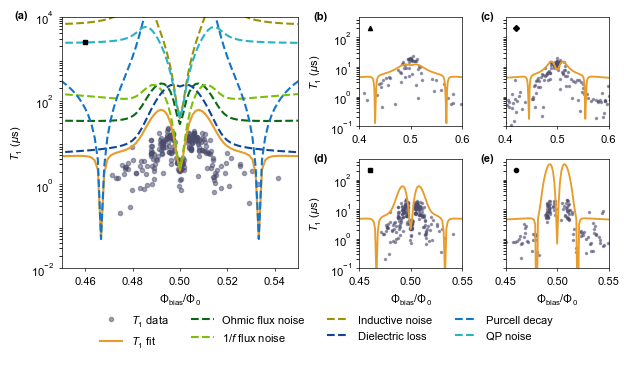

In [23]:
plot_results(dataset_keys, results)

In [97]:
phi_target = 0.5

dataset_key = '3'
selected = phi_2_datasets[dataset_key]
r = results[dataset_key]
T1_total = r["T_total"]
phi_ext = r["phi_ext"]
f01 = r["f01"]

T1_total_at_sweet_spot = np.interp(phi_target, phi_ext, T1_total)
f01_at_sweet_spot = np.interp(phi_target, phi_ext, f01)

print(f"T_total at phi_ext = {phi_target} is {T1_total_at_sweet_spot*1e6:.2f} µs")
print(f"f01 at phi_ext = {phi_target} is {f01_at_sweet_spot:.4f} GHz")

T_total at phi_ext = 0.5 is 2.13 µs
f01 at phi_ext = 0.5 is 0.4027 GHz


# Fitting

In [39]:
# Concatenate all datasets
flux_all = []
T1_all = []

for key in dataset_keys:
    selected = phi_2_datasets[key]
    flux_all.append(selected['flux_data'].values)
    T1_all.append(selected['t1_data'].values)

flux_all = np.concatenate(flux_all)
T1_all = np.concatenate(T1_all)

T1_all = np.concatenate([phi_2_datasets[key]['t1_data'].values for key in dataset_keys])
dummy_flux = np.zeros_like(T1_all)  # ignored by the function

flux2  = selected['phi_2']


flux_data = selected['flux_data']
t1_data = selected['t1_data']


In [26]:
T1_all = np.concatenate([phi_2_datasets[key]['t1_data'].values for key in dataset_keys])
dummy_flux = np.zeros_like(T1_all)  # ignored by the function

In [27]:
print("Data length (T1_all):", len(T1_all))

Data length (T1_all): 621


In [28]:
len(dummy_flux)

621

In [29]:
def T1_model_func_global_for_fit(dummy_flux, M1, M2, A_cap, alpha_cap, A_lambda, gamma, x_qp):
    """
    Compute T1 for all datasets using the same parameters and return a single 1D array
    for curve_fit. dummy_flux is ignored.
    """
    T1_all = []
    
    for key in dataset_keys:
        selected = phi_2_datasets[key]
        flux1 = selected['flux_data'].values
        phi2 = selected['phi_2']

        # Compute T1 for this dataset
        EJeff, flux1_noise, flux2_noise, qp_noise_op, n01, f01, phi_op, qp_op_alt = compute_qubit_properties(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        flux1=flux1,
        flux2=flux2,
        phi=phi,
        Ec=EC, ng=ng,
        n_max=n_max
        )

        Gamma_flux1_line, Gamma_flux2_line, Gamma_flux_total = FBL_noise_mix(f01, flux1_noise, flux2_noise, M1, M2)
        
        Gamma_charge = Charge_noise(EC, f01, n01, A_cap, alpha_cap)

        Gamma_one_over_f = one_over_f_noise(f01, flux1_noise, flux2_noise, A_lambda, gamma)
        
        Gamma_QP_alt = Gamma1_qp(T, f01, qp_op_alt, x_qp )

        Gamma_total = Gamma_flux_total + Gamma_charge + Gamma_QP_alt + Gamma_one_over_f
        
        T1_all.append(1 / Gamma_total)
    
    return np.concatenate(T1_all)


In [30]:
n_max = 50

In [31]:
initial_guess = [1500, 1800, 5e6, 0.7, 1e-5, 1.0, 3e-6]  # M1, M2, A_cap, alpha_cap, A_lambda, gamma, x_qp
lower_bounds = [1500, 1500, 0.5e5, 0.7, 1e-6, 0.999, 3e-7]
upper_bounds = [3000, 3000, 5e6, 1, 1e-4, 1.0, 1e-5]

popt, pcov = curve_fit(
    T1_model_func_global_for_fit,
    dummy_flux,
    T1_all,
    p0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    maxfev=100
)

ValueError: too many values to unpack (expected 8)

In [ ]:
M1_fit, M2_fit, A_cap_fit, alpha_cap_fit, A_lambda_fit, gamma_fit, x_qp_fit = popt
print(
    f"M1 = {M1_fit:.1f}, "
    f"M2 = {M2_fit:.1f}, "
    f"A_cap = {A_cap_fit:.2e}, "
    f"alpha_cap = {alpha_cap_fit:.3f}, "
    f"A_lambda = {A_lambda_fit:.2e}, "
    f"gamma = {gamma_fit:.3f}, "
    f"x_qp = {x_qp_fit:.2e}"
)


M1 = 2460.8, M2 = 2803.0, A_cap = 8.09e+05, alpha_cap = 0.384, A_lambda = 2.98e-05, gamma = 0.865, x_qp = 5.63e-06


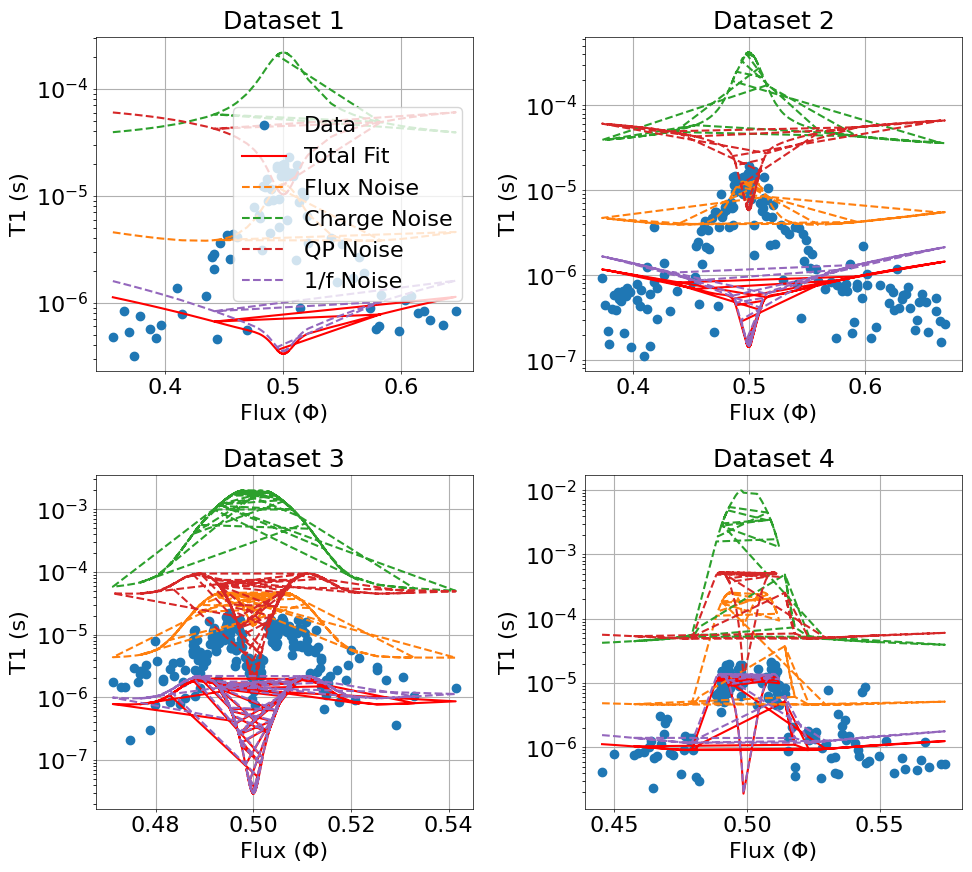

In [ ]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'mathtext.fontset': 'dejavusans',
})

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for i, key in enumerate(dataset_keys):
    selected = phi_2_datasets[key]
    
    flux1 = selected['flux_data'].values
    T1_data_vals = selected['t1_data'].values
    phi2 = selected['phi_2']

    # ✅ Use REAL flux1 (not linspace!)
    phi_ext = flux1

    # --- Compute qubit properties ---
    EJeff, flux1_noise, flux2_noise, qp_noise_op, n01, f01, phi_op, qp_op_alt = compute_qubit_properties(
        EJ1, EJ2, EJ3, EJ4, EJ5,
        flux1,        # ✅ correct
        phi2,
        phi,
        EC,
        ng
    )

    # --- Noise contributions (MATCH FIT MODEL) ---
    _, _, Gamma_flux_total = FBL_noise_mix(f01, flux1_noise, flux2_noise, M1_fit, M2_fit)

    Gamma_charge = Charge_noise(EC, f01, n01, A_cap_fit, alpha_cap_fit)

    Gamma_one_over_f = one_over_f_noise(
        f01, flux1_noise, flux2_noise,
        A_lambda_fit, gamma_fit
    )

    Gamma_QP_alt = Gamma1_qp(T, f01, qp_op_alt, x_qp_fit)

    # --- Total ---
    Gamma_total = Gamma_flux_total + Gamma_charge + Gamma_QP_alt + Gamma_one_over_f
    T1_fit = 1 / Gamma_total

    # --- Individual contributions ---
    T1_flux = 1 / Gamma_flux_total
    T1_charge = 1 / Gamma_charge
    T1_qp = 1 / Gamma_QP_alt
    T1_1f = 1 / Gamma_one_over_f

    # --- Sanity check ---
    assert len(T1_fit) == len(flux1), \
        f"Shape mismatch: {len(T1_fit)} vs {len(flux1)}"

    # --- Plot ---
    ax = axes[i]

    ax.plot(flux1, T1_data_vals, 'o', label='Data')
    ax.plot(flux1, T1_fit, '-', label='Total Fit', color='red')

    ax.plot(flux1, T1_flux, '--', label='Flux Noise')
    ax.plot(flux1, T1_charge, '--', label='Charge Noise')
    ax.plot(flux1, T1_qp, '--', label='QP Noise')
    ax.plot(flux1, T1_1f, '--', label='1/f Noise')

    ax.set_title(f"Dataset {key}")
    ax.set_xlabel("Flux (Φ)")
    ax.set_ylabel("T1 (s)")
    ax.set_yscale('log')
    ax.grid(True)

# Optional legend only once (cleaner)
axes[0].legend()

plt.tight_layout()
plt.show()